# Notebook 05: AMSR2 Comparison

Matches CRYO2ICE snow thickness estimates against AMSR2 passive-microwave
snow depth for benchmarking. Uses Southern Hemisphere EASE grid (EPSG:3409).

## 5.1 Setup

In [6]:
import sys, glob, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, '/g/data/gv90/xl1657/phd/M2_workspace/notebooks')
from utils import read_amsr2_sh, match_amsr2_nn

HS_DIR = '/g/data/gv90/xl1657/phd/M2_workspace/output/snow_thickness'
AMSR2_DIR = '/g/data/gv90/xl1657/phd/M2_workspace/data/auxiliary/AMSR2'
FIG_DIR = '/g/data/gv90/xl1657/phd/M2_workspace/output/figures'

print('Setup complete')


Setup complete


## 5.2 Load CRYO2ICE Snow Thickness Results

In [7]:
df = pd.read_csv('/g/data/gv90/xl1657/phd/M2_workspace/output/snow_thickness/snow_thickness_202208.csv')
print(f'Loaded {len(df)} matchups')
print(f'Months: {sorted(df.year_month.unique())}')


Loaded 11822 matchups
Months: [202208]


## 5.3 Test AMSR2 Reader on a Single File

In [8]:
amsr2_files = sorted(glob.glob(f'{AMSR2_DIR}/*.he5'))
print(f'Found {len(amsr2_files)} AMSR2 files')

# Test on first file
df_amsr2_test = read_amsr2_sh(amsr2_files[0])
print(f'AMSR2 grid points: {len(df_amsr2_test)}')
print(f'SIC range: {df_amsr2_test.sea_ice_concentration.min():.0f} to '
      f'{df_amsr2_test.sea_ice_concentration.max():.0f}')
print(f'Snow depth range: {df_amsr2_test.snow_depth.min():.3f} to '
      f'{df_amsr2_test.snow_depth.max():.3f} m')


Found 1541 AMSR2 files
AMSR2 grid points: 419648
SIC range: 0 to 120
Snow depth range: 0.000 to 1.500 m


In [9]:
import h5py

with h5py.File(amsr2_files[0], 'r') as f:
    print(f"File: {amsr2_files[0]}")
    print("\n=== Full structure ===")
    f.visit(lambda name: print(f"  {name}"))

File: /g/data/gv90/xl1657/phd/M2_workspace/data/auxiliary/AMSR2/AMSR_U2_L3_SeaIce12km_B04_20200731.he5

=== Full structure ===
  DOI
  HDFEOS
  HDFEOS/ADDITIONAL
  HDFEOS/ADDITIONAL/FILE_ATTRIBUTES
  HDFEOS/GRIDS
  HDFEOS/GRIDS/NpPolarGrid12km
  HDFEOS/GRIDS/NpPolarGrid12km/Data Fields
  HDFEOS/GRIDS/NpPolarGrid12km/Data Fields/SI_12km_NH_18H_ASC
  HDFEOS/GRIDS/NpPolarGrid12km/Data Fields/SI_12km_NH_18H_DAY
  HDFEOS/GRIDS/NpPolarGrid12km/Data Fields/SI_12km_NH_18H_DSC
  HDFEOS/GRIDS/NpPolarGrid12km/Data Fields/SI_12km_NH_18V_ASC
  HDFEOS/GRIDS/NpPolarGrid12km/Data Fields/SI_12km_NH_18V_DAY
  HDFEOS/GRIDS/NpPolarGrid12km/Data Fields/SI_12km_NH_18V_DSC
  HDFEOS/GRIDS/NpPolarGrid12km/Data Fields/SI_12km_NH_23H_ASC
  HDFEOS/GRIDS/NpPolarGrid12km/Data Fields/SI_12km_NH_23H_DAY
  HDFEOS/GRIDS/NpPolarGrid12km/Data Fields/SI_12km_NH_23H_DSC
  HDFEOS/GRIDS/NpPolarGrid12km/Data Fields/SI_12km_NH_23V_ASC
  HDFEOS/GRIDS/NpPolarGrid12km/Data Fields/SI_12km_NH_23V_DAY
  HDFEOS/GRIDS/NpPolarGrid12km/

## 5.4 Match AMSR2 to CRYO2ICE Locations

For each CRYO2ICE matchup, find the nearest AMSR2 grid cell.
This is done on a monthly basis, using the AMSR2 file closest to the middle of each month.

In [10]:
import os
# Check filename pattern
print(os.path.basename(amsr2_files[0]))
print(os.path.basename(amsr2_files[0]).split('_'))

AMSR_U2_L3_SeaIce12km_B04_20200731.he5
['AMSR', 'U2', 'L3', 'SeaIce12km', 'B04', '20200731.he5']


In [11]:
# Build date lookup for AMSR2 files
# Filename pattern: AMSR_U2_L3_SeaIce12km_B04_YYYYMMDD.he5
amsr2_by_date = {}
for f in amsr2_files:
    basename = os.path.basename(f)
    # Pattern: AMSR_U2_L3_SeaIce12km_B04_20200731.he5
    # Date is in the last part before .he5
    parts = basename.replace('.he5', '').split('_')
    for p in parts:
        if len(p) == 8 and p.isdigit():
            amsr2_by_date[p] = f
            break

print(f'AMSR2 dates indexed: {len(amsr2_by_date)}')
print(f'First date: {sorted(amsr2_by_date.keys())[0]}')
print(f'Last date:  {sorted(amsr2_by_date.keys())[-1]}')

print(f'AMSR2 dates indexed: {len(amsr2_by_date)}')

# For each month, pick mid-month AMSR2 file
matched_with_amsr2 = []
for ym in sorted(df.year_month.unique()):
    from datetime import datetime, timedelta
    mid_date = datetime.strptime(f'{ym}15', '%Y%m%d')
    available = sorted(amsr2_by_date.keys())
    closest = min(available, key=lambda d: abs((datetime.strptime(d, '%Y%m%d') - mid_date).days))
    days_diff = abs((datetime.strptime(closest, '%Y%m%d') - mid_date).days)

    if days_diff > 31:
        print(f'{ym}: No AMSR2 within 31 days (closest: {closest}, {days_diff} days), skipping')
        continue

    # Read AMSR2
    df_amsr2 = read_amsr2_sh(amsr2_by_date[closest])

    # Filter to valid AMSR2 data
    df_amsr2 = df_amsr2[(df_amsr2.sea_ice_concentration > 0) &
                        (df_amsr2.sea_ice_concentration <= 100) &
                        (df_amsr2.snow_depth >= 0) &
                        (df_amsr2.snow_depth <= 1.5)]

    # Get CRYO2ICE data for this month
    df_month = df[df.year_month == ym].copy()
    if len(df_month) == 0:
        continue

    # Match
    df_matched = match_amsr2_nn(df_month, df_amsr2)
    matched_with_amsr2.append(df_matched)
    print(f'{ym}: matched {len(df_matched)} pts with AMSR2 date {closest}')

df_comp = pd.concat(matched_with_amsr2, ignore_index=True)
print(f'\nTotal with AMSR2: {len(df_comp)}')


AMSR2 dates indexed: 1541
First date: 20200731
Last date:  20250831
AMSR2 dates indexed: 1541
202208: matched 11822 pts with AMSR2 date 20220815

Total with AMSR2: 11822


## 5.5 Comparison Plots

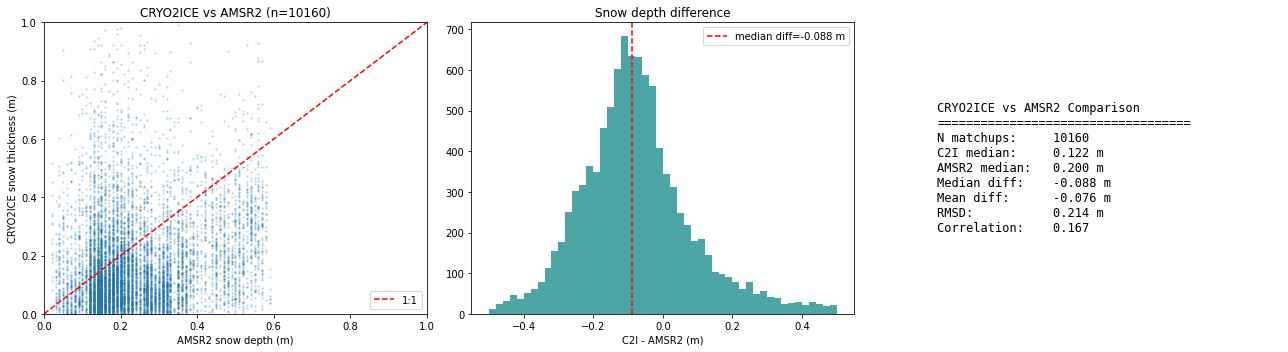

In [12]:
valid = (df_comp.snow_thickness > 0) & (df_comp.AMSR2_snow_depth > 0)
c2i = df_comp.snow_thickness[valid]
amsr = df_comp.AMSR2_snow_depth[valid]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter: C2I vs AMSR2
ax = axes[0]
ax.scatter(amsr, c2i, s=2, alpha=0.2)
ax.plot([0, 1], [0, 1], 'r--', label='1:1')
ax.set_xlabel('AMSR2 snow depth (m)')
ax.set_ylabel('CRYO2ICE snow thickness (m)')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title(f'CRYO2ICE vs AMSR2 (n={valid.sum()})')
ax.legend()

# Difference histogram
ax = axes[1]
diff = c2i.values - amsr.values
ax.hist(diff, bins=50, range=(-0.5, 0.5), color='teal', alpha=0.7)
ax.axvline(np.nanmedian(diff), color='red', ls='--',
           label=f'median diff={np.nanmedian(diff):.3f} m')
ax.set_xlabel('C2I - AMSR2 (m)')
ax.set_title('Snow depth difference')
ax.legend()

# Statistics text
ax = axes[2]
ax.axis('off')
stats_text = (
    f'CRYO2ICE vs AMSR2 Comparison\n'
    f'{"=" * 35}\n'
    f'N matchups:     {valid.sum()}\n'
    f'C2I median:     {c2i.median():.3f} m\n'
    f'AMSR2 median:   {amsr.median():.3f} m\n'
    f'Median diff:    {np.nanmedian(diff):.3f} m\n'
    f'Mean diff:      {np.nanmean(diff):.3f} m\n'
    f'RMSD:           {np.sqrt(np.nanmean(diff**2)):.3f} m\n'
    f'Correlation:    {np.corrcoef(c2i, amsr)[0,1]:.3f}'
)
ax.text(0.1, 0.5, stats_text, transform=ax.transAxes,
        fontsize=12, family='monospace', va='center')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/05_amsr2_comparison_202208.png', dpi=300)
plt.show()

## 5.6 Save Results

In [13]:
df_comp.to_csv(f'{HS_DIR}/snow_thickness_with_amsr2_202208.csv', index=False)
print(f'Saved {len(df_comp)} rows with AMSR2 comparison')


Saved 11822 rows with AMSR2 comparison
